# Week11 - Part1: Red Color Tracking and Hand Detection


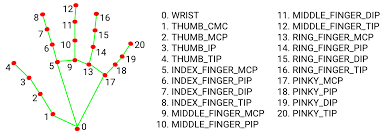

In [ ]:
# !pip install mediapipe
# !pip uninstall mediapipe
# !pip install mediapipe==0.10.9

^C


ERROR: Could not find a version that satisfies the requirement mediapipe==0.10.9 (from versions: 0.10.13, 0.10.14, 0.10.18, 0.10.20, 0.10.21, 0.10.30, 0.10.31, 0.10.32)
ERROR: No matching distribution found for mediapipe==0.10.9


In [1]:
import cv2
import numpy as np
import mediapipe as mp
from collections import deque


# Setup tracking memory
pts =deque(maxlen=20)  # Store the last 20 points for tracking path


# Setup MediaPipe Hand
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils



# Initizlize Hand tacking model
hands = mp_hands.Hands(
    static_image_mode=False,  # For video stream, set to False
    max_num_hands=2,         # Maximum number of hands to detect
    min_detection_confidence=0.7,  # Minimum confidence for hand detection
    min_tracking_confidence=0.7    # Minimum confidence for hand tracking
)

# Initialize webcam 
cap = cv2.VideoCapture(0)

# Loop 
while True:
    # Capture frame by frame
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame")
        break
    

  
    # Flip the frame horizontally for a "mirror" effect
    frame = cv2.flip(frame, 1)

    # RED object tacking

    # Apply gaussian blur to reduce nopise
    blurred = cv2.GaussianBlur(frame, (11, 11), 0)

    # Convert color from RGB to HSV 
    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
    
    
    # Red color occupies two range in HSV
    # Lower range of red
    lower_red1 = np.array([0, 120, 70])
    upper_red1 = np.array([10, 255, 255])
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    # Upper range of red
    lower_red2 = np.array([170, 120, 70])
    upper_red2 = np.array([180, 255, 255])
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    # Combine both mask 
    mask = mask1 + mask2
    mask = cv2.erode(mask, None, iterations=2)
    mask = cv2.dilate(mask, None, iterations=2)
    # Find contours of the red shape in the mask
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    center = None
    # Process only if at least on contour was found
    if len(cnts) > 0:
        # Find the largest contour
        c = max(cnts, key=cv2.contourArea)
        ((x, y), radius) = cv2.minEnclosingCircle(c)
        M = cv2.moments(c)
        # Calculate coordinates only if the object has a valid area
        if M['m00'] != 0:
            center = (int(M['m10']/M['m00']), int(M['m01']/M['m00']))

            if radius > 10:
                cv2.circle(frame, center, 5, (0, 0, 255), 2)
                cv2.circle(frame, (int(x), int(y)), int(radius), (0, 255, 255), 2)

                coord_text = f"X: {center[0]} Y: {center[1]}"
                cv2.putText(
                    frame,
                    coord_text,
                    (center[0] + 10,center[1] - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (255, 255, 255),
                    2
                )

    # Draw tracking path
    # Update and draw the movement paht
 
        # Line thickness adt small for older points
        

   
    # HAND DETECTION
    # MediaPipe requires RGB image, OpenCV uses BGR
    
    # Detect hands
   
    # If hands are detected in the frame
    # if results.multi_hand_landmarks:
    #     for hand_landmarks in results.multi_hand_landmarks:

            # Draw hand landmarks (21 landmarks)
           

            # Calculate hand center
          
            
            # Convert normalized landmark coordinates to pixel coordinates
           
            
            # Calculate Hadk center
            

            # Draw center point
            
            # Display the X, Y coordinated of hand
        
    # show the result
    cv2.imshow("Red Object Tracking and Hand Detection", frame)
    # Stop the program if 'q' is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
# Cleanup
cap.release()
cv2.destroyAllWindows()

ImportError: cannot import name 'runtime_version' from 'google.protobuf' (c:\Users\jinny\.conda\envs\defeat\Lib\site-packages\google\protobuf\__init__.py)